In [1]:
import numpy as np

kernel = np.array([1/9]*9).reshape(3, 3)

kernel

array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]])

이미지의 픽셀값의 자료형은 보통 `unit8` (0~255, 8bit unsigned)

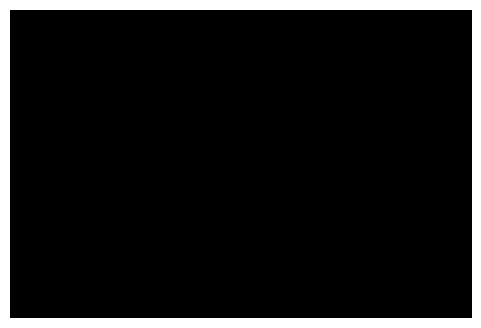

In [3]:
height = 80
width = 120

# 검정 사진 만들기
img = np.zeros((height, width), dtype=np.uint8)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

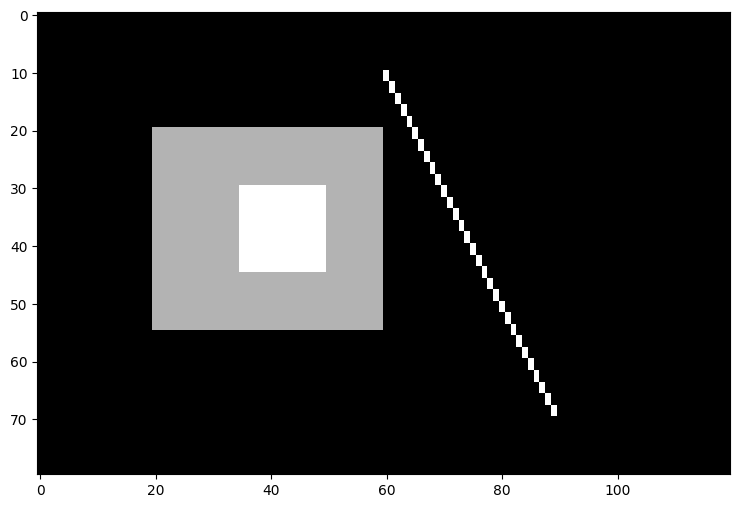

In [6]:
# height = 80
# width = 120

img[20:55, 20:60] = 180

img[30:45, 35:50] = 255

for i in range(60):
  img[i+10, 60+i//2] = 255

n=3
plt.figure(figsize=(3*n, 2*n))

plt.imshow(img, cmap="gray", vmin=0, vmax=255)
# plt.axis("off")
plt.show()


In [7]:
kernel

array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]])

In [8]:
def my_convolve2d(image, kernel):
  """2차원 이미지에 2차원 커널을 적용하는 함수. 반환크기는 원본과 같음"""
  
  image_h, image_w = image.shape
  kernel_h, kernel_w = kernel.shape

  # 커널의 반지름
  pad_h = kernel_h //2
  pad_w = kernel_w //2

  # 가장자리 처리를 위해 패딩 추가
  padded = np.pad(
    image,
    pad_width=(
      (pad_h, pad_h), # 이미지 위아래에 패딩 (0) 넣기
      (pad_w, pad_w)  # 이미지 좌우에 패딩 (0) 넣기
    ), 
    mode="edge"
  )

  # 이미지와 동일한 크기의 0만 있는 배열 만들기
  output = np.zeros_like(image, dtype=np.float64) 

  # 이미지의 모든 픽셀 위치에 대해 반복
  for y in range(image_h):
    for x in range(image_w):
      # 현재 위치 영역 잘라내기
      region = padded[y:y+kernel_h, x:x+kernel_w]

      # 주변 영역과 커널을 곱한 뒤 모두 더하기
      value = np.sum(region * kernel)

      # 결과 저장
      output[y, x] = value

  return output

[[0.02777778 0.02777778 0.02777778 0.02777778 0.02777778 0.02777778]
 [0.02777778 0.02777778 0.02777778 0.02777778 0.02777778 0.02777778]
 [0.02777778 0.02777778 0.02777778 0.02777778 0.02777778 0.02777778]
 [0.02777778 0.02777778 0.02777778 0.02777778 0.02777778 0.02777778]
 [0.02777778 0.02777778 0.02777778 0.02777778 0.02777778 0.02777778]
 [0.02777778 0.02777778 0.02777778 0.02777778 0.02777778 0.02777778]]


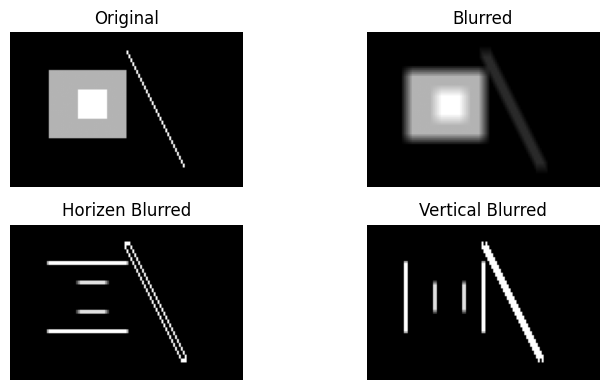

In [39]:
def make_kernel(n: int):
  print(np.array([1/(n*n)]*(n*n)).reshape(n, n))
  return np.array([1/(n*n)]*(n*n)).reshape(n, n)

def make_hor_kernel(n_arr, step_strength):
  n_arr = np.array(n_arr)
  arr = np.array([])
  for i in range(1, len(n_arr)+1):
    arr = np.append(arr, n_arr*step_strength*i)

  print(arr.reshape(-1, len(n_arr)))
  return arr.reshape(-1, len(n_arr))



# blurred = 

n = 4
plt.figure(figsize=(2*n, 1*n))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(my_convolve2d(img, make_kernel(6)), cmap="gray", vmin=0, vmax=255)
plt.title("Blurred")
plt.axis("off")

# 위에서 아래로 더 밝아지는 (증가하는) 구간만 뽑아서 보여주기
horizontal_kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

plt.subplot(2, 2, 3)
plt.imshow(abs(my_convolve2d(img, horizontal_kernel)), cmap="gray", vmin=0, vmax=255)
plt.title("Horizen Blurred")
plt.axis("off")

# 오른쪽으로 더 밝아지는 (증가하는) 구간만 뽑아서 보여주기
vertical_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

plt.subplot(2, 2, 4)
plt.imshow(abs(my_convolve2d(img, vertical_kernel)), cmap="gray", vmin=0, vmax=255)
plt.title("Vertical Blurred")
plt.axis("off")

plt.tight_layout()

plt.show()

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


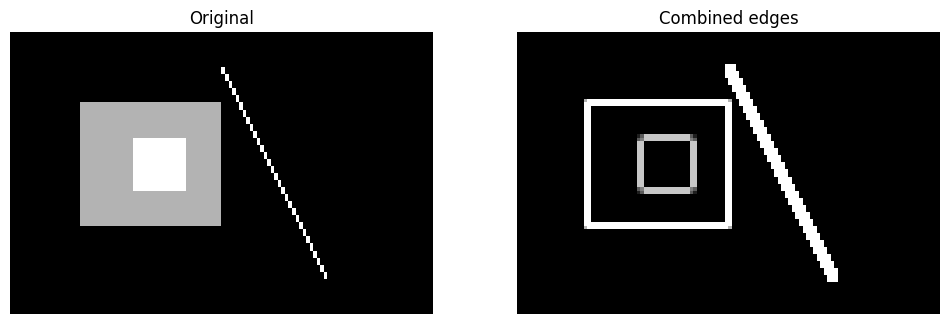

In [38]:
h = my_convolve2d(img, horizontal_kernel)**2 
v = my_convolve2d(img, vertical_kernel)**2
edge = (np.sqrt(h**2 + v**2)/255)

print(h)
print(v)
print(edge)

# edge = (edge / edge.max()) * 255

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edge, cmap="gray", vmin=0, vmax=255)
plt.title("Combined edges")
plt.axis("off")

plt.show()